<a href="https://colab.research.google.com/github/serenalxs/Practice/blob/main/MnistPractice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
## install torch
!pip install torch torchvision

##install mlflow
!pip install mlflow matplotlib


In [23]:
import torch
import torchvision
import numpy as np
from torchvision import datasets
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt


# **Download data**

# **ToTensor:**

1) convert to Tensor

2) format piture format as channel,height,length (convert normal picture to tensor pictures in 3 dimension in computer : channel , height, length)

3) normalize picture to between 0 and 1 (normal picture is 255 format, normalize to 0 and 1)


In [24]:
train_ds = torchvision.datasets.MNIST ('data', train=True, transform=ToTensor(),download=True)
test_ds = torchvision.datasets.MNIST ('data', train=False, transform=ToTensor(),download=True)

torch.utils.data.DataLoader:

1. shuffle the data
2. split data to batch_size
3. num_workers : use multiple CPU


In [25]:
train_dl = torch.utils.data.DataLoader (train_ds,batch_size =64, shuffle =True)
test_dl = torch.utils.data.DataLoader (test_ds,batch_size =64) #test data doesn't need shuffle

In [26]:
# img: saved all pictures
# label : picture's label

img, label = next (iter (train_dl))

print(img.shape) #channel, height, weigth # 64 picture, each 1 (black and white picture), 28X28 picture
print (label)

torch.Size([64, 1, 28, 28])
tensor([1, 4, 4, 3, 0, 8, 9, 1, 1, 6, 2, 6, 0, 7, 0, 7, 7, 3, 7, 3, 5, 4, 4, 0,
        8, 6, 1, 3, 7, 9, 6, 6, 0, 4, 9, 8, 7, 5, 9, 0, 6, 3, 7, 0, 6, 7, 2, 7,
        2, 4, 1, 5, 1, 0, 8, 1, 9, 6, 5, 9, 1, 0, 6, 4])


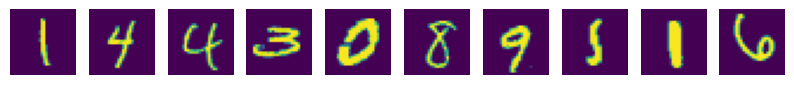

In [27]:
plt.figure (figsize = (10,1))
for i , img in enumerate(img[:10]) :
  npimg = img.numpy()
  npimg = np.squeeze(npimg)
  plt.subplot (1,10,i+1)
  plt.imshow (npimg)
  plt.axis ('off')



# ***Model***

Flattern the input for nn.Linear() : Input picture dimension is (64,1,28,28) : 64 picture,black&white,28X28.

64: # of samples
1X28X28:  1 sample's dimension

Have to flattern it to 64 X n. Therefore, (1,28,28) is flatten to 1X28X28

Dropout: Dropout (p = dropout_p)

for each of hidden layer, can randomly set up some nodes as 0 which work like being droppout. p is the probability that a node is deactivated in a given training pass.

In [28]:
from torch import nn

class Model (nn.Module) :
  def __init__ (self) :
    super().__init__()
    self.linear_1 = nn.Linear(1*28*28, 120)
    self.linear_2 = nn.Linear(120,84)
    self.dropout_2 = nn.Dropout (p = 0.5)
    self.linear_3 = nn.Linear(84,10) #output is 0~9, so 10 categories. So output is 10 dimension. Later using softmax to summarize 10 dimension to 1 dimension.
  def forward (self, input) :
    x = input.view(-1,28*28)  #-1: flatten to 1 dimension
    x = torch.relu(self.linear_1(x))
    x = torch.relu(self.linear_2(x))
    x = self.dropout_2(x)
    logits = self.linear_3(x)    #logits is output, don't need to activate
    return logits

#loss function : (input is logits which haven't been activated)
loss_fn = torch.nn.CrossEntropyLoss()

#initialize model:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = Model().to(device)

#optimization:
opt = torch.optim.SGD(model.parameters(),lr = 0.01)




In [29]:
# training function
def train (dl, model, loss_fn, opt) :
    size = len(dl.dataset) #total number of samples in all batches
    num_batch = len(dl) # how many batches

    train_loss, correct = 0 , 0


    for x , y in dl :
      x , y = x.to(device) , y.to(device)
      pred = model(x)
      loss = loss_fn(pred, y)
      opt.zero_grad()
      loss.backward()
      opt.step()

      with torch.no_grad() :
        correct += (pred.argmax(1) == y).type(torch.float).sum().item() # dimension 1: batch number ; dimension 2: prediction value
        train_loss += loss.item()

    correct /= size #total correct
    train_loss /= num_batch #avg loss

    return correct, train_loss

In [30]:
# test function
def test (test_dl, model, loss_fn) :
    size = len(test_dl.dataset) #total number of samples in all batches
    num_batch = len(test_dl) # how many batches

    test_loss, correct = 0 , 0

    with torch.no_grad() :
      for x , y in test_dl :
        x , y = x.to(device) , y.to(device)
        pred = model(x)
        loss = loss_fn(pred, y)

        correct += (pred.argmax(1) == y).type(torch.float).sum().item() # dimension 1: batch number ; dimension 2: prediction value
        test_loss += loss.item()

    correct /= size #total correct
    test_loss /= num_batch #avg loss

    return correct, test_loss

In [31]:
# build fit function to output results
def fit (epochs, train_dl, test_dl, model, loss_fn, opt) :
  # train 50 epoch. Each epoch represents training the whole dataset for once.

  train_loss = []
  train_acc = []
  test_loss = []
  test_acc = []

  for epoch in range(epochs) :
    epoch_acc , epoch_loss = train(train_dl, model,loss_fn, opt = opt)
    epoch_test_acc , epoch_test_loss = test(test_dl, model,loss_fn)
    train_acc.append(epoch_acc)
    train_loss.append(epoch_loss)
    test_acc.append(epoch_test_acc)
    test_loss.append(epoch_test_loss)

    template = ("epoch:{:2d}, train_loss:{:.5f} , train_acc:{:.1f},test_loss:{:.5f} , test_acc:{:.1f} ")
    print(template.format(epoch, epoch_loss, epoch_acc*100,epoch_test_loss, epoch_test_acc*100))
  print ("Done")
  return epochs, train_loss, train_acc, test_loss, test_acc


#loss function : (input is logits which haven't been activated)
loss_fn = torch.nn.CrossEntropyLoss()

#initialize model:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = Model().to(device)

#optimization:
opt = torch.optim.SGD(model.parameters(),lr = 0.01)

#training and output
epochs, train_loss, train_acc, test_loss, test_acc =  fit (10,train_dl, test_dl,model, loss_fn, opt)





epoch: 0, train_loss:1.79123 , train_acc:47.2,test_loss:1.05217 , test_acc:67.5 
epoch: 1, train_loss:0.80328 , train_acc:75.7,test_loss:0.62450 , test_acc:81.4 
epoch: 2, train_loss:0.57930 , train_acc:83.0,test_loss:0.52080 , test_acc:84.9 
epoch: 3, train_loss:0.49633 , train_acc:86.0,test_loss:0.46435 , test_acc:86.7 
epoch: 4, train_loss:0.44615 , train_acc:87.3,test_loss:0.41871 , test_acc:88.2 
epoch: 5, train_loss:0.41136 , train_acc:88.4,test_loss:0.37831 , test_acc:89.1 
epoch: 6, train_loss:0.38251 , train_acc:89.2,test_loss:0.35891 , test_acc:89.5 
epoch: 7, train_loss:0.35916 , train_acc:89.9,test_loss:0.34094 , test_acc:90.5 
epoch: 8, train_loss:0.33909 , train_acc:90.5,test_loss:0.32877 , test_acc:90.7 
epoch: 9, train_loss:0.32126 , train_acc:91.1,test_loss:0.31155 , test_acc:91.1 
Done


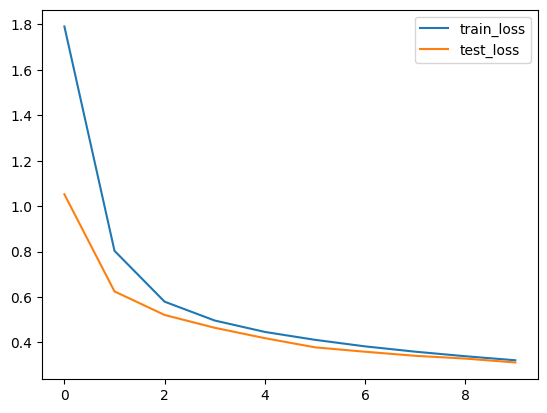

In [32]:
import matplotlib.pyplot as plt

plt.plot(range(epochs), train_loss, label = 'train_loss')
plt.plot(range(epochs), test_loss, label ='test_loss')
plt.legend()


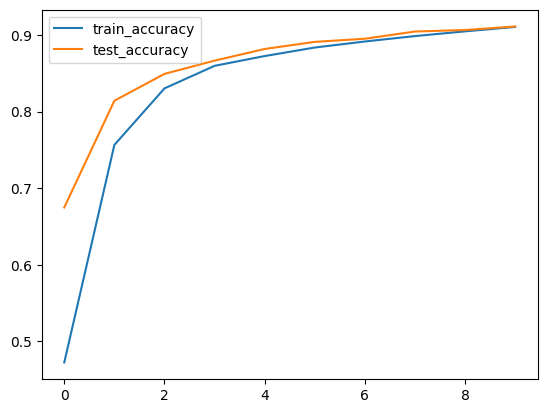

In [33]:
plt.plot(range(epochs), train_acc, label = 'train_accuracy')
plt.plot(range(epochs), test_acc, label ='test_accuracy')
plt.legend()

# **Learning rate:**

Big enough to make loss decrease efficiently

Small enough to make able to find local loss low point